# Water Quality Classification Model - Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\Nishant\Downloads\Water_quality_dataset.csv")

In [3]:
df

,Record ID,Temperature,Turbidity (cm),Dissolved Oxygen (mg L-1),Biochemical Oxygen Demand (mg L-1),Carbon Dioxide (mg L-1),pH,Total Alkalinity (mg L-1 as CaCO3),Total Hardness (mg L-1 as CaCO3),Calcium (mg L-1),...,Ammonia (mg L-1),Nitrite (mg L-1),Phosphorus (mg L-1),Hydrogen Sulphide (mg L-1),Plankton Abundance (No. L-1),Water Quality Index (WQI),WQI-Derived Quality Label,WQI-Derived Quality Category,WQI-Derived Aquaculture Suitability Classification,WQI-Derived Aquaculture Suitability Description
0,1,31.200,13.535,0.222,6.393,8.077,6.703,240.671,645.052,152.765,...,0.929,0.094,0.200,0.040,2190,54.10,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
1,2,31.066,42.971,3.475,7.121,9.950,6.457,281.103,710.607,164.371,...,0.644,0.072,0.200,0.027,558,74.81,2,Good/Marginal,Suitable,Standard Suitability: Water is generally safe ...
2,3,31.090,41.791,3.764,7.541,3.201,8.220,242.452,601.083,140.578,...,1.963,0.099,0.200,0.040,2001,69.90,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
3,4,15.241,10.005,3.339,6.615,9.187,6.714,275.743,132.707,8.577,...,1.828,0.086,0.391,0.028,804,69.16,3,Poor/Marginal,Restricted / Stressed,Reduced Suitability: Water is significantly im...
4,5,31.077,10.726,0.556,7.654,3.121,8.252,265.220,524.329,116.310,...,1.703,0.097,0.432,0.038,718,48.57,4,Very Poor/Unsuitable,Unsuitable / Critical,"Critical Risk: Water is heavily contaminated, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,4296,26.109,62.264,6.331,1.099,2.091,7.706,110.348,161.318,42.562,...,0.021,0.001,0.010,0.001,6513,97.52,1,Excellent/Good,Highly Suitable,Optimal Suitability: Water is clean and suitab...
4296,4297,25.684,68.401,6.409,1.087,1.976,7.801,103.662,178.041,47.876,...,0.021,0.001,0.011,0.001,5996,97.10,1,Excellent/Good,Highly Suitable,Optimal Suitability: Water is clean and suitab...
4297,4298,25.911,65.209,6.487,1.056,2.186,7.755,104.658,159.268,42.700,...,0.021,0.001,0.016,0.001,6272,97.34,1,Excellent/Good,Highly Suitable,Optimal Suitability: Water is clean and suitab...
4298,4299,25.737,70.750,6.545,1.068,1.846,7.765,109.715,161.817,42.773,...,0.021,0.001,0.017,0.001,6161,97.28,1,Excellent/Good,Highly Suitable,Optimal Suitability: Water is clean and suitab...


In [4]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 21 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Record ID                                           4300 non-null   int64  
 1   Temperature                                         4300 non-null   float64
 2   Turbidity (cm)                                      4300 non-null   float64
 3   Dissolved Oxygen (mg L-1)                           4300 non-null   float64
 4   Biochemical Oxygen Demand (mg L-1)                  4300 non-null   float64
 5   Carbon Dioxide (mg L-1)                             4300 non-null   float64
 6   pH                                                  4300 non-null   float64
 7   Total Alkalinity (mg L-1 as CaCO3)                  4300 non-null   float64
 8   Total Hardness (mg L-1 as CaCO3)                    4300 non-null   float64
 9

,Record ID,Temperature,Turbidity (cm),Dissolved Oxygen (mg L-1),Biochemical Oxygen Demand (mg L-1),Carbon Dioxide (mg L-1),pH,Total Alkalinity (mg L-1 as CaCO3),Total Hardness (mg L-1 as CaCO3),Calcium (mg L-1),Estimated Magnesium (mg L-1),Ammonia (mg L-1),Nitrite (mg L-1),Phosphorus (mg L-1),Hydrogen Sulphide (mg L-1),Plankton Abundance (No. L-1),Water Quality Index (WQI),WQI-Derived Quality Label
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,2150.500000,22.949140,43.205610,4.491523,3.421510,3.543107,7.687135,139.738163,188.795357,44.780682,18.693055,0.266785,0.029351,0.130650,0.011536,4170.274186,85.287193,1.656977
std,1241.447408,3.246538,20.127224,2.099080,1.906087,1.750644,0.418724,49.401477,105.491477,26.899298,10.770020,0.326582,0.024986,0.120195,0.011358,1889.176922,14.915235,0.921814
min,1.000000,15.000000,10.000000,0.200000,1.000000,1.668000,6.000000,100.000000,25.815000,5.000000,2.753000,0.020000,0.001000,0.010000,0.001000,500.000000,46.660000,1.000000
25%,1075.750000,19.990000,29.401750,2.032000,1.109000,2.159750,7.631000,107.134250,125.924000,24.922000,12.887000,0.022000,0.001000,0.022000,0.001000,2170.750000,67.630000,1.000000
50%,2150.500000,24.303000,37.798500,5.462000,3.454500,3.248000,7.729000,114.986500,164.322500,42.598000,14.846500,0.115000,0.027000,0.112500,0.007000,4050.500000,93.965000,1.000000
75%,3225.250000,25.622000,63.497750,6.393000,5.139000,4.048000,7.939000,160.314000,219.003750,50.519500,22.952250,0.524000,0.050000,0.202000,0.024000,6041.250000,97.252500,3.000000
max,4300.000000,32.000000,81.060000,6.587000,8.000000,10.000000,8.500000,300.000000,763.341000,180.000000,76.531000,2.000000,0.100000,0.500000,0.050000,6596.000000,97.910000,4.000000


In [5]:
df.isnull().sum()

Record ID                                             0
Temperature                                           0
Turbidity (cm)                                        0
Dissolved Oxygen (mg L-1)                             0
Biochemical Oxygen Demand (mg L-1)                    0
Carbon Dioxide (mg L-1)                               0
pH                                                    0
Total Alkalinity (mg L-1 as CaCO3)                    0
Total Hardness (mg L-1 as CaCO3)                      0
Calcium (mg L-1)                                      0
Estimated Magnesium (mg L-1)                          0
Ammonia (mg L-1)                                      0
Nitrite (mg L-1)                                      0
Phosphorus (mg L-1)                                   0
Hydrogen Sulphide (mg L-1)                            0
Plankton Abundance (No. L-1)                          0
Water Quality Index (WQI)                             0
WQI-Derived Quality Label                       

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.drop_duplicates(inplace=True)

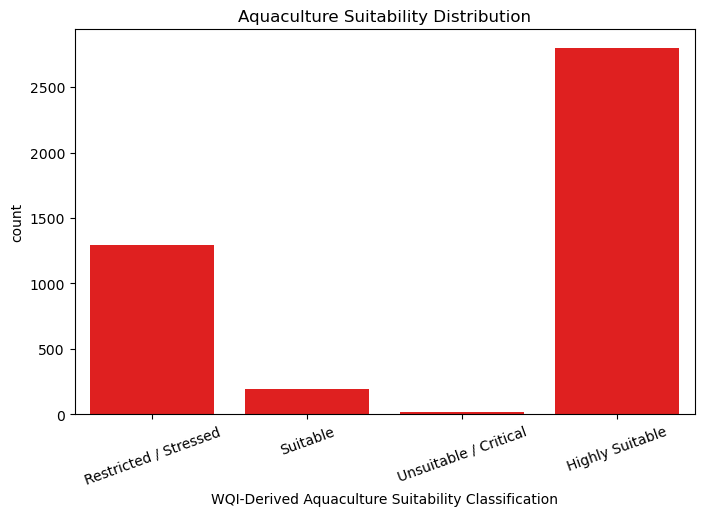

In [8]:
plt.figure(figsize=(8,5))
sns.countplot( x='WQI-Derived Aquaculture Suitability Classification',
    data=df,color="Red")
plt.xticks(rotation=20)
plt.title("Aquaculture Suitability Distribution")
plt.show()

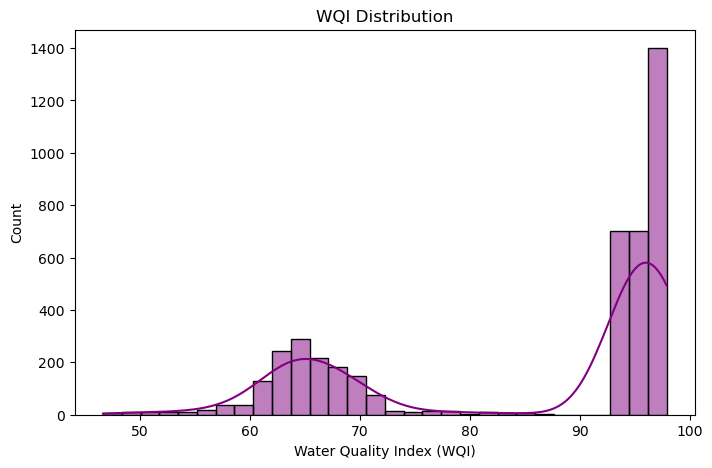

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Water Quality Index (WQI)'],bins=30,kde=True,color="Purple")
plt.title("WQI Distribution")
plt.show()

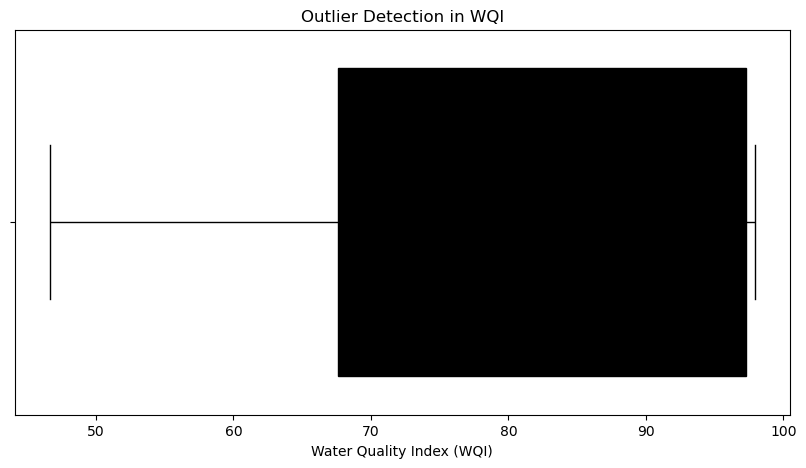

In [10]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Water Quality Index (WQI)'],color="Black")
plt.title("Outlier Detection in WQI")
plt.show()

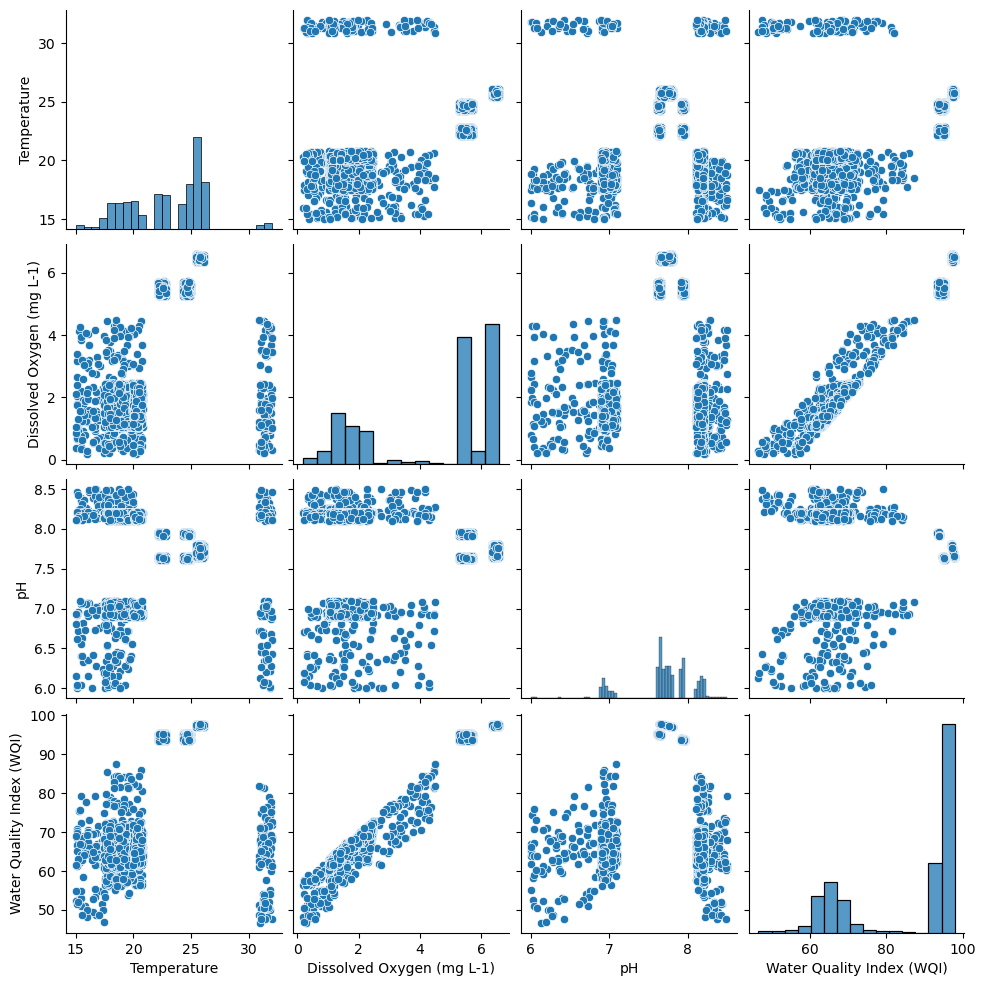

In [11]:
cols = ['Temperature','Dissolved Oxygen (mg L-1)','pH','Water Quality Index (WQI)']
sns.pairplot(df[cols])
plt.show()

In [12]:
# Feature Selection-Removing text columns and leakage columns 

X = df.drop(columns=[
    'Record ID',
    'WQI-Derived Aquaculture Suitability Classification',
    'WQI-Derived Aquaculture Suitability Description',
    'WQI-Derived Quality Category'])
y = df['WQI-Derived Aquaculture Suitability Classification']

In [13]:
le = LabelEncoder()
y = le.fit_transform(y)

In [14]:
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred = rf.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 100.0 %


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       535
           1       1.00      1.00      1.00       284
           2       1.00      1.00      1.00        39
           3       1.00      1.00      1.00         2

    accuracy                           1.00       860
   macro avg       1.00      1.00      1.00       860
weighted avg       1.00      1.00      1.00       860



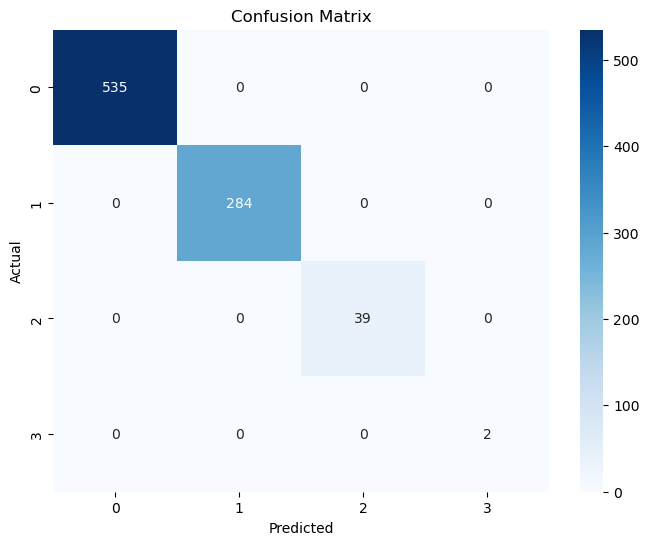

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance',ascending=False)
importance.head(10)

,Feature,Importance
16,WQI-Derived Quality Label,0.170485
2,Dissolved Oxygen (mg L-1),0.167245
15,Water Quality Index (WQI),0.153663
3,Biochemical Oxygen Demand (mg L-1),0.100453
12,Phosphorus (mg L-1),0.099897
14,Plankton Abundance (No. L-1),0.091229
13,Hydrogen Sulphide (mg L-1),0.084588
11,Nitrite (mg L-1),0.063485
10,Ammonia (mg L-1),0.055861
1,Turbidity (cm),0.006914


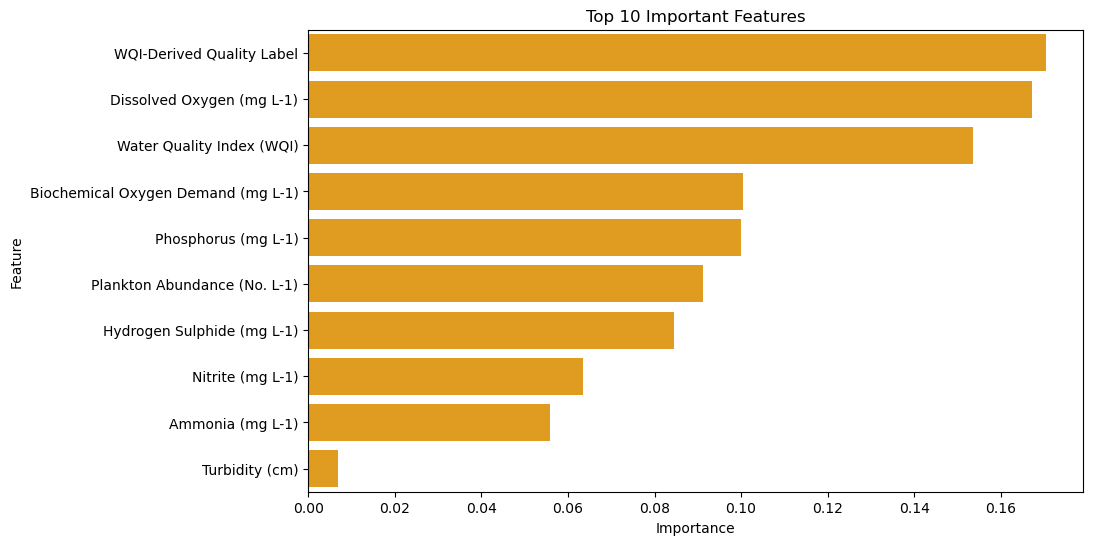

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='Feature',color="Orange",data=importance.head(10))
plt.title("Top 10 Important Features")
plt.show()